In [4]:
!pip install gensim nltk matplotlib seaborn
import nltk
nltk.download("punkt_tab")
import gensim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from nltk.corpus import reuters
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
nltk.download("punkt")
nltk.download("reuters")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package reuters to /root/nltk_data...


True

Top 5 words similar to 'disease':
[('level', 0.9969637989997864), ('grain', 0.9969517588615417), ('sharply', 0.996946394443512), ('trading', 0.9969313740730286), ('late', 0.9969091415405273)]


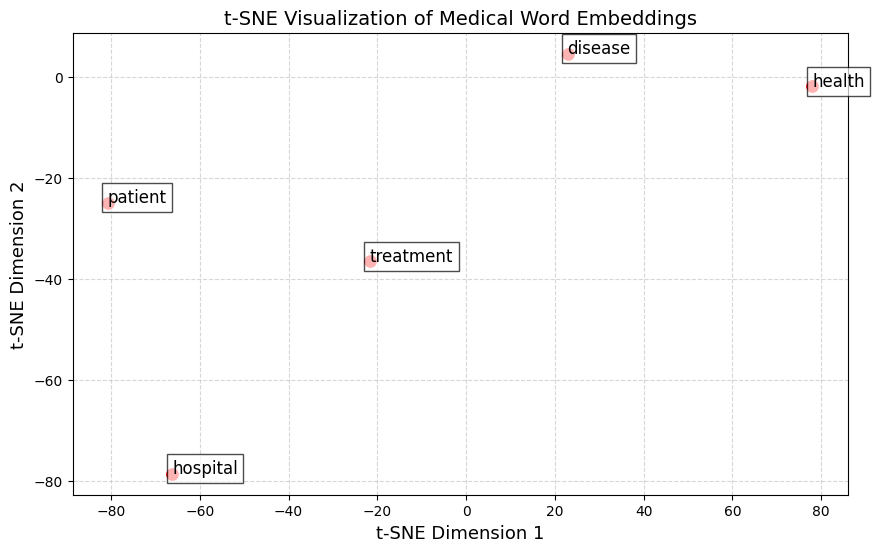

In [6]:
corpus = reuters.sents()[:5000]
medical_sentences = [[word.lower() for word in sent if word.isalpha()] for sent in corpus]
model = Word2Vec(sentences=medical_sentences, vector_size=100, window=5, min_count=2, workers=4)
model.save("medical_word2vec.model")
model = Word2Vec.load("medical_word2vec.model")
medical_term = "disease"
if medical_term in model.wv:
    print(f"Top 5 words similar to '{medical_term}':")
    print(model.wv.most_similar(medical_term, topn=5))
else:
    print(f"'{medical_term}' not found in vocabulary.")

selected_words = ["health", "disease", "doctor", "patient", "treatment", "medicine", "virus", "surgery", "nurse", "hospital"]


words_to_plot = []
vectors_to_plot = []
for word in selected_words:
    if word in model.wv:
        words_to_plot.append(word)
        vectors_to_plot.append(model.wv[word])


if len(vectors_to_plot) > 0:
    word_vectors = np.array(vectors_to_plot)
    tsne = TSNE(n_components=2, random_state=42, perplexity=3)
    word_vectors_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=word_vectors_2d[:, 0], y=word_vectors_2d[:, 1], s=100, color="red")

    for i, word in enumerate(words_to_plot):
        plt.annotate(word, (word_vectors_2d[i, 0], word_vectors_2d[i, 1]), fontsize=12, bbox=dict(facecolor='white', alpha=0.7))

    plt.title("t-SNE Visualization of Medical Word Embeddings", fontsize=14)
    plt.xlabel("t-SNE Dimension 1", fontsize=13)
    plt.ylabel("t-SNE Dimension 2", fontsize=13)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
else:
    print("None of the selected words were found in the model's vocabulary to plot.")